# 🛒 Desconto como Alavanca ou Armadilha?
### Uma análise de pricing estratégico no e-commerce Amazon

**Autora:** Marielle Romani  
**Dataset:** Amazon Products Sales Dataset 2023 — 551k produtos, 142 categorias  
**Objetivo:** Identificar o equilíbrio entre política de desconto e satisfação do cliente, gerando recomendações acionáveis por categoria

---


## PARTE 1 — Contexto de Negócio

### Por que pricing não é só colocar preço baixo?

No e-commerce, desconto é uma faca de dois gumes. Usado bem, ele **acelera conversão** e aumenta volume. Usado sem critério, ele **destrói percepção de valor** — e o cliente começa a achar que o produto "só vale" quando está em promoção.

A Amazon opera com centenas de categorias simultâneas. Cada uma tem dinâmica diferente:
- Em **eletrônicos**, o consumidor pesquisa muito — desconto pode ser decisivo
- Em **moda**, desconto excessivo pode sinalizar baixa qualidade
- Em **beleza premium**, o preço é parte do produto — cortar demais afasta o público certo

### As 3 perguntas que este projeto responde

| # | Pergunta | Decisão de negócio |
|---|---|---|
| 1 | Qual a relação entre % de desconto e avaliação por categoria? | Onde o desconto está corroendo satisfação? |
| 2 | Quais categorias têm melhor equilíbrio ticket × satisfação? | Onde focar investimento? |
| 3 | Existe um "ponto ótimo" de desconto? | Qual o teto antes de prejudicar valor percebido? |

### Hipóteses iniciais

- **H1:** Descontos acima de 50% correlacionam com avaliações mais baixas
- **H2:** Categorias de alto ticket têm avaliações mais estáveis, independente do desconto
- **H3:** Produtos com muitas avaliações tendem a notas mais estáveis (regressão à média)
- **H4:** Existe uma faixa ótima de desconto (20–40%) onde avaliação é maximizada


## PARTE 2 — Setup e Carregamento dos Dados

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 6)
sns.set_style("whitegrid")

COLORS = {
    'primary':   '#FF9900',
    'secondary': '#232F3E',
    'accent':    '#146EB4',
    'danger':    '#E74C3C',
    'success':   '#2ECC71',
    'neutral':   '#95A5A6'
}

print("✅ Bibliotecas carregadas")


✅ Bibliotecas carregadas


In [2]:
df_raw = pd.read_csv('Amazon-Products.csv')
print(f"📦 Shape: {df_raw.shape}")
print(f"📋 Colunas: {list(df_raw.columns)}")
df_raw.head(3)


📦 Shape: (551585, 10)
📋 Colunas: ['Unnamed: 0', 'name', 'main_category', 'sub_category', 'image', 'link', 'ratings', 'no_of_ratings', 'discount_price', 'actual_price']


,Unnamed: 0,name,main_category,sub_category,image,link,ratings,no_of_ratings,discount_price,actual_price
0,0,Lloyd 1.5 Ton 3 Star Inverter Split Ac (5 In 1...,appliances,Air Conditioners,https://m.media-amazon.com/images/I/31UISB90sY...,https://www.amazon.in/Lloyd-Inverter-Convertib...,4.2,"2,255","₹32,999","₹58,990"
1,1,LG 1.5 Ton 5 Star AI DUAL Inverter Split AC (C...,appliances,Air Conditioners,https://m.media-amazon.com/images/I/51JFb7FctD...,https://www.amazon.in/LG-Convertible-Anti-Viru...,4.2,"2,948","₹46,490","₹75,990"
2,2,LG 1 Ton 4 Star Ai Dual Inverter Split Ac (Cop...,appliances,Air Conditioners,https://m.media-amazon.com/images/I/51JFb7FctD...,https://www.amazon.in/LG-Inverter-Convertible-...,4.2,"1,206","₹34,490","₹61,990"


## PARTE 3 — Limpeza e Tratamento

> Os preços estão em rúpias indianas (₹) com vírgulas de milhar.  
> O campo `no_of_ratings` contém ruído textual (ex: "FREE Delivery by Amazon") — tratamos com conversão segura.


In [3]:
def clean_price(val):
    if pd.isna(val): return np.nan
    try:
        return float(str(val).replace('₹','').replace(',','').strip())
    except:
        return np.nan

def clean_no_ratings(val):
    """Converte numero de avaliações — ignora textos misturados no campo"""
    if pd.isna(val): return np.nan
    cleaned = str(val).replace(',','').strip()
    try:
        v = float(cleaned)
        return v if v < 1_000_000 else np.nan  # remove outliers absurdos
    except:
        return np.nan  # descarta textos como "FREE Delivery by Amazon"

df = df_raw.copy()
df['actual_price_clean']   = df['actual_price'].apply(clean_price)
df['discount_price_clean'] = df['discount_price'].apply(clean_price)
df['ratings_clean']        = pd.to_numeric(df['ratings'], errors='coerce')
df['no_of_ratings_clean']  = df['no_of_ratings'].apply(clean_no_ratings)

df['discount_pct'] = (
    (df['actual_price_clean'] - df['discount_price_clean'])
    / df['actual_price_clean'] * 100
).round(1)

bins   = [0, 20, 40, 60, 80, 101]
labels = ['0–20%', '21–40%', '41–60%', '61–80%', '81–100%']
df['faixa_desconto'] = pd.cut(df['discount_pct'], bins=bins, labels=labels, right=True)

df_clean = df.dropna(subset=['actual_price_clean','discount_pct','ratings_clean','main_category'])
df_clean = df_clean[(df_clean['discount_pct'] >= 0) & (df_clean['ratings_clean'] > 0)]

print(f"✅ Dados originais:    {len(df_raw):,} linhas")
print(f"✅ Após limpeza:       {len(df_clean):,} linhas")
print(f"📊 Categorias únicas:  {df_clean['main_category'].nunique()}")
print(f"💰 Ticket mediano:     ₹{df_clean['actual_price_clean'].median():,.0f}")
print(f"🏷️  Desconto médio:    {df_clean['discount_pct'].mean():.1f}%")


✅ Dados originais:    551,585 linhas
✅ Após limpeza:       334,963 linhas
📊 Categorias únicas:  20
💰 Ticket mediano:     ₹1,499
🏷️  Desconto médio:    51.0%


## PARTE 4 — Análise Exploratória (EDA)

### 4.1 Distribuição geral de preços e descontos

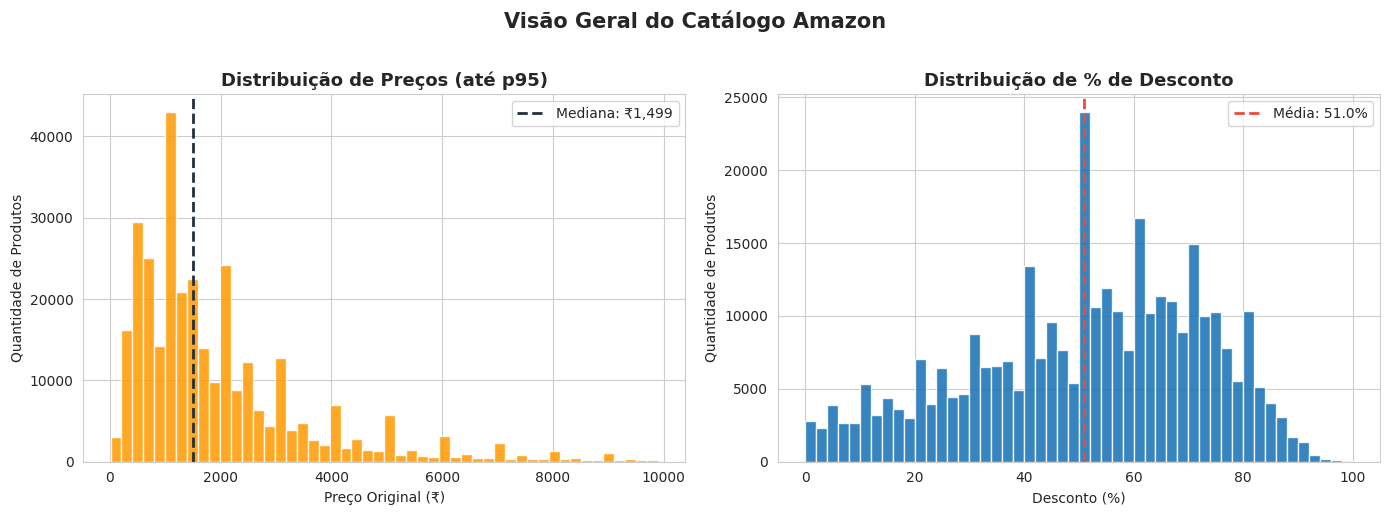


💡 Insight: A maioria dos produtos tem desconto entre 30–60%, sinalizando estratégia promocional agressiva e generalizada.


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

price_cap = df_clean['actual_price_clean'].quantile(0.95)
ax1 = axes[0]
ax1.hist(df_clean[df_clean['actual_price_clean'] <= price_cap]['actual_price_clean'],
         bins=50, color=COLORS['primary'], edgecolor='white', alpha=0.85)
ax1.axvline(df_clean['actual_price_clean'].median(), color=COLORS['secondary'],
            linestyle='--', linewidth=2,
            label=f"Mediana: ₹{df_clean['actual_price_clean'].median():,.0f}")
ax1.set_title('Distribuição de Preços (até p95)', fontsize=13, fontweight='bold')
ax1.set_xlabel('Preço Original (₹)')
ax1.set_ylabel('Quantidade de Produtos')
ax1.legend()

ax2 = axes[1]
ax2.hist(df_clean['discount_pct'], bins=50, color=COLORS['accent'], edgecolor='white', alpha=0.85)
ax2.axvline(df_clean['discount_pct'].mean(), color=COLORS['danger'],
            linestyle='--', linewidth=2,
            label=f"Média: {df_clean['discount_pct'].mean():.1f}%")
ax2.set_title('Distribuição de % de Desconto', fontsize=13, fontweight='bold')
ax2.set_xlabel('Desconto (%)')
ax2.set_ylabel('Quantidade de Produtos')
ax2.legend()

plt.suptitle('Visão Geral do Catálogo Amazon', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig1_distribuicao.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n💡 Insight: A maioria dos produtos tem desconto entre 30–60%, sinalizando estratégia promocional agressiva e generalizada.")


### 4.2 Top categorias por volume, ticket médio e desconto

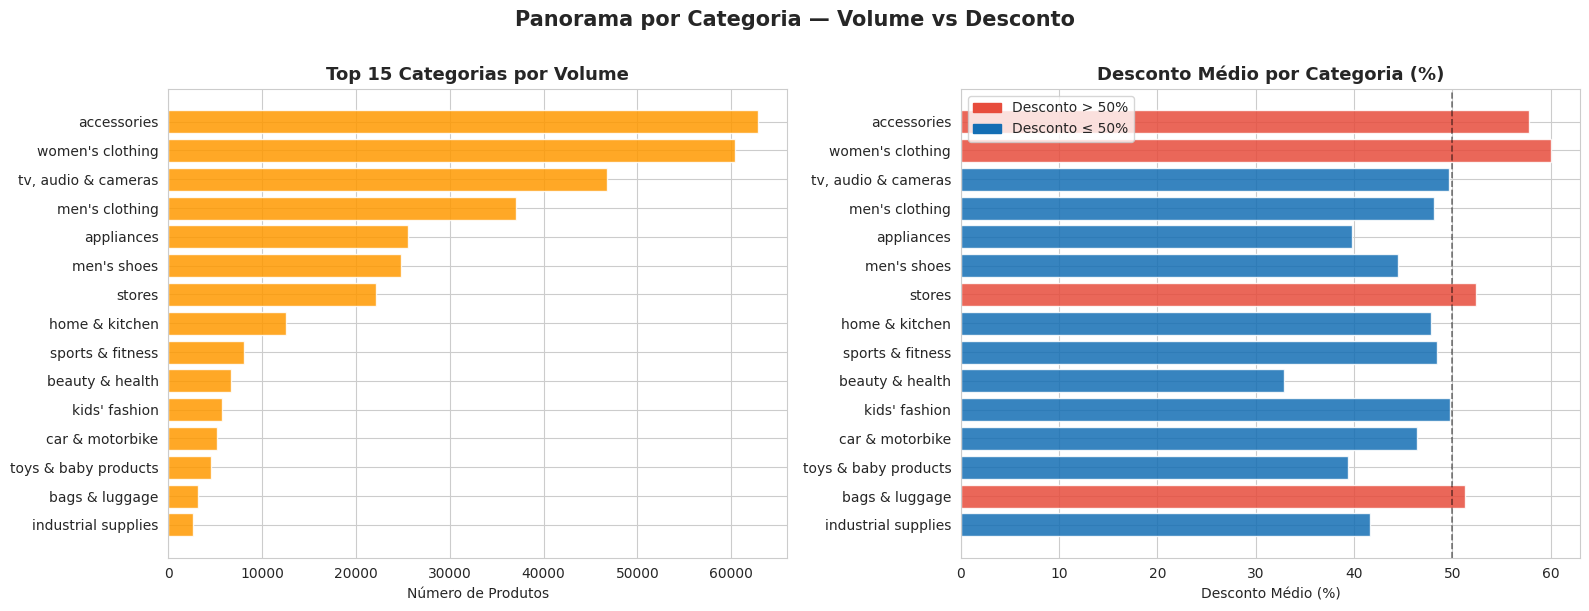


📋 Top 10 categorias:
      main_category  n_produtos  ticket_medio  desconto_medio  avaliacao_media
        accessories       62869        1670.0       57.791245         3.893068
   women's clothing       60447        1499.0       59.971810         3.754719
tv, audio & cameras       46756        1599.0       49.653788         3.817645
     men's clothing       37025        1499.0       48.161839         3.751430
         appliances       25547        2090.0       39.761365         3.843524
        men's shoes       24833        2499.0       44.444127         3.599170
             stores       22191        1543.0       52.360678         3.863711
     home & kitchen       12524         999.0       47.795608         3.974760
   sports & fitness        8028        1299.0       48.473443         3.795765
    beauty & health        6723         549.0       32.841499         3.985691


In [5]:
cat_summary = df_clean.groupby('main_category').agg(
    n_produtos      =('ratings_clean','count'),
    ticket_medio    =('actual_price_clean','median'),
    desconto_medio  =('discount_pct','mean'),
    avaliacao_media =('ratings_clean','mean')
).reset_index().sort_values('n_produtos', ascending=False)

top15 = cat_summary.head(15)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax1 = axes[0]
ax1.barh(top15['main_category'], top15['n_produtos'], color=COLORS['primary'], alpha=0.85)
ax1.set_title('Top 15 Categorias por Volume', fontsize=13, fontweight='bold')
ax1.set_xlabel('Número de Produtos')
ax1.invert_yaxis()

ax2 = axes[1]
colors_bar = [COLORS['danger'] if x > 50 else COLORS['accent'] for x in top15['desconto_medio']]
ax2.barh(top15['main_category'], top15['desconto_medio'], color=colors_bar, alpha=0.85)
ax2.axvline(50, color='black', linestyle='--', linewidth=1.2, alpha=0.5)
ax2.set_title('Desconto Médio por Categoria (%)', fontsize=13, fontweight='bold')
ax2.set_xlabel('Desconto Médio (%)')
ax2.invert_yaxis()
red_p  = mpatches.Patch(color=COLORS['danger'], label='Desconto > 50%')
blue_p = mpatches.Patch(color=COLORS['accent'], label='Desconto ≤ 50%')
ax2.legend(handles=[red_p, blue_p])

plt.suptitle('Panorama por Categoria — Volume vs Desconto', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig2_categorias.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📋 Top 10 categorias:")
print(top15[['main_category','n_produtos','ticket_medio','desconto_medio','avaliacao_media']].head(10).to_string(index=False))


### 4.3 Outliers: o que acontece com produtos com desconto > 70%?

> **Hipótese:** Descontos extremos podem indicar produtos de baixa qualidade sendo 'empurrados' via preço.

🚨 Produtos com desconto > 70%: 70,718 (21.1% do catálogo)
   Avaliação média (desconto > 70%): 3.73 ⭐
   Avaliação média (desconto ≤ 70%): 3.84 ⭐
   Diferença: -0.10 pontos


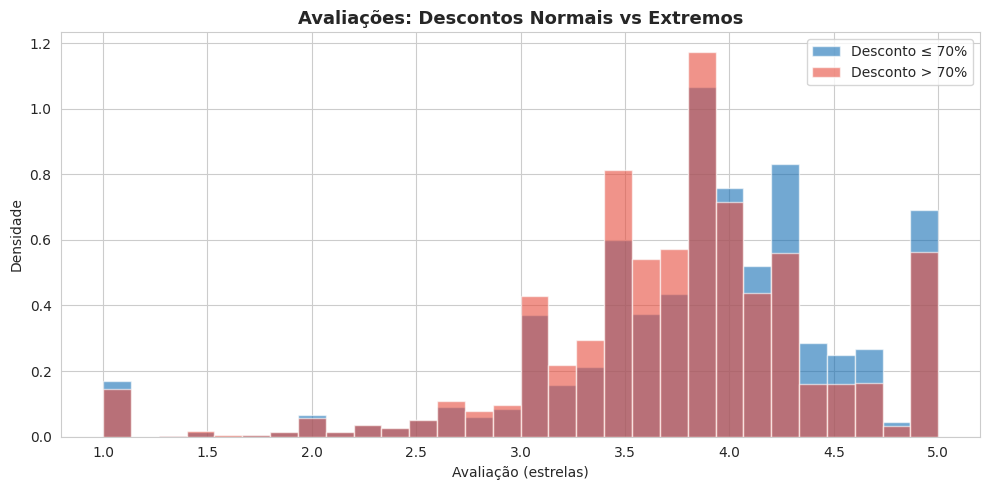


💡 Insight: Descontos extremos não compensam insatisfação — o problema não é de preço, é de produto.


In [6]:
outliers = df_clean[df_clean['discount_pct'] > 70]
normais  = df_clean[df_clean['discount_pct'] <= 70]

print(f"🚨 Produtos com desconto > 70%: {len(outliers):,} ({len(outliers)/len(df_clean)*100:.1f}% do catálogo)")
print(f"   Avaliação média (desconto > 70%): {outliers['ratings_clean'].mean():.2f} ⭐")
print(f"   Avaliação média (desconto ≤ 70%): {normais['ratings_clean'].mean():.2f} ⭐")
print(f"   Diferença: {outliers['ratings_clean'].mean() - normais['ratings_clean'].mean():.2f} pontos")

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(normais['ratings_clean'],  bins=30, alpha=0.6, color=COLORS['accent'],  label='Desconto ≤ 70%', density=True)
ax.hist(outliers['ratings_clean'], bins=30, alpha=0.6, color=COLORS['danger'], label='Desconto > 70%',  density=True)
ax.set_title('Avaliações: Descontos Normais vs Extremos', fontsize=13, fontweight='bold')
ax.set_xlabel('Avaliação (estrelas)')
ax.set_ylabel('Densidade')
ax.legend()
plt.tight_layout()
plt.savefig('fig3_outliers.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n💡 Insight: Descontos extremos não compensam insatisfação — o problema não é de preço, é de produto.")


## PARTE 5 — Análise de Correlação

### 5.1 Desconto vs Avaliação — a relação geral

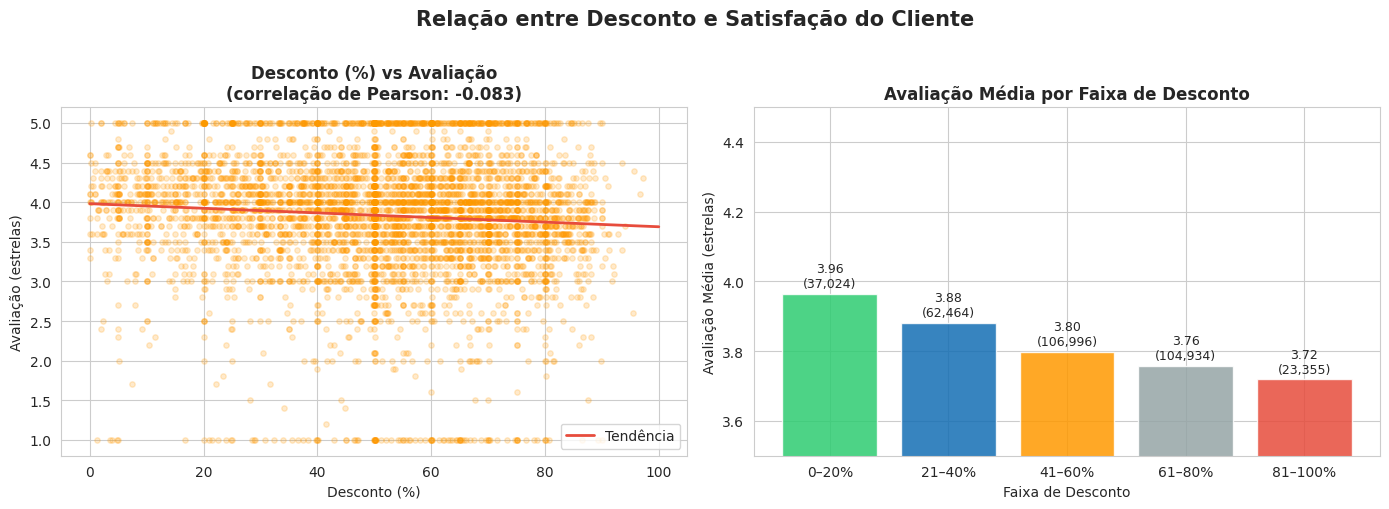

In [7]:
sample = df_clean.sample(n=min(5000, len(df_clean)), random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1 = axes[0]
ax1.scatter(sample['discount_pct'], sample['ratings_clean'], alpha=0.2, color=COLORS['primary'], s=15)
z = np.polyfit(sample['discount_pct'].dropna(), sample['ratings_clean'].dropna(), 1)
p = np.poly1d(z)
x_line = np.linspace(0, 100, 100)
ax1.plot(x_line, p(x_line), color=COLORS['danger'], linewidth=2, label='Tendência')
corr = sample['discount_pct'].corr(sample['ratings_clean'])
ax1.set_title(f'Desconto (%) vs Avaliação\n(correlação de Pearson: {corr:.3f})', fontsize=12, fontweight='bold')
ax1.set_xlabel('Desconto (%)')
ax1.set_ylabel('Avaliação (estrelas)')
ax1.legend()

ax2 = axes[1]
faixa_avg = df_clean.groupby('faixa_desconto', observed=True)['ratings_clean'].agg(['mean','count']).reset_index()
bar_colors = [COLORS['success'], COLORS['accent'], COLORS['primary'], COLORS['neutral'], COLORS['danger']]
bars = ax2.bar(faixa_avg['faixa_desconto'].astype(str), faixa_avg['mean'], color=bar_colors, alpha=0.85, edgecolor='white')
ax2.set_title('Avaliação Média por Faixa de Desconto', fontsize=12, fontweight='bold')
ax2.set_xlabel('Faixa de Desconto')
ax2.set_ylabel('Avaliação Média (estrelas)')
ax2.set_ylim(3.5, 4.5)
for bar, (_, row) in zip(bars, faixa_avg.iterrows()):
    ax2.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
             f"{row['mean']:.2f}\n({row['count']:,})", ha='center', va='bottom', fontsize=9)

plt.suptitle('Relação entre Desconto e Satisfação do Cliente', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig4_correlacao.png', dpi=150, bbox_inches='tight')
plt.show()


### 5.2 Volume de avaliações valida qualidade?

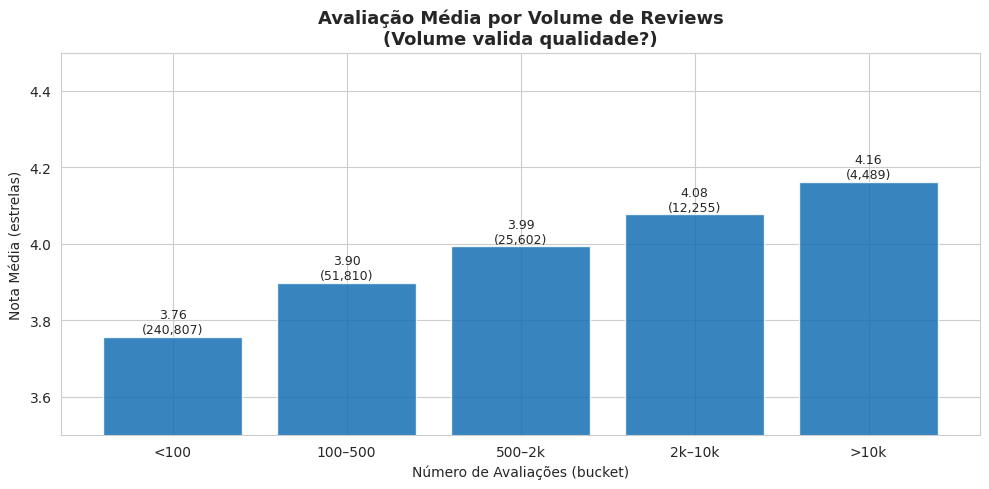


💡 Insight: Produtos com mais reviews têm notas mais estáveis — a sabedoria das multidões reduz distorções.


In [8]:
df_clean['bucket_reviews'] = pd.cut(
    df_clean['no_of_ratings_clean'],
    bins=[0, 100, 500, 2000, 10000, float('inf')],
    labels=['<100', '100–500', '500–2k', '2k–10k', '>10k']
)

bucket_avg = df_clean.groupby('bucket_reviews', observed=True)['ratings_clean'].agg(['mean','count']).reset_index()

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(bucket_avg['bucket_reviews'].astype(str), bucket_avg['mean'],
       color=COLORS['accent'], alpha=0.85, edgecolor='white')
ax.set_title('Avaliação Média por Volume de Reviews\n(Volume valida qualidade?)', fontsize=13, fontweight='bold')
ax.set_xlabel('Número de Avaliações (bucket)')
ax.set_ylabel('Nota Média (estrelas)')
ax.set_ylim(3.5, 4.5)
for i, (_, row) in enumerate(bucket_avg.iterrows()):
    ax.text(i, row['mean'] + 0.01, f"{row['mean']:.2f}\n({int(row['count']):,})", ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('fig5_volume_reviews.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n💡 Insight: Produtos com mais reviews têm notas mais estáveis — a sabedoria das multidões reduz distorções.")


### 5.3 Heatmap de correlações

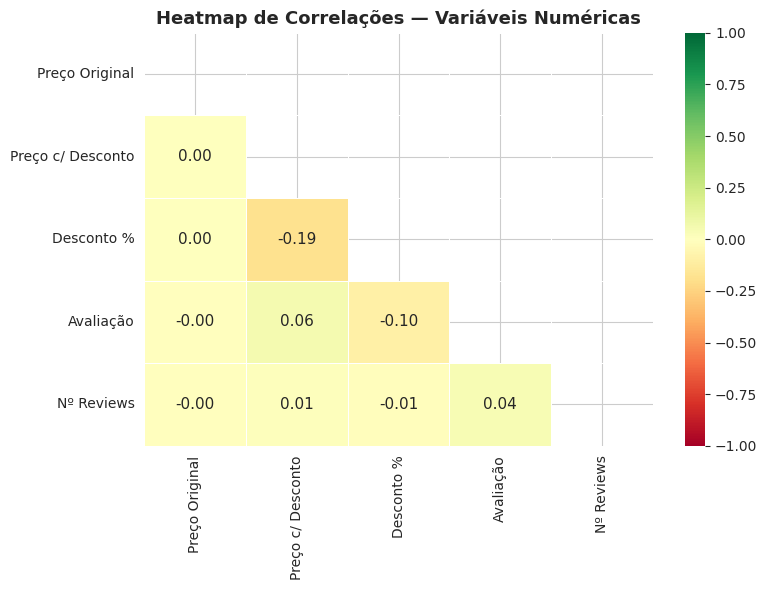

In [9]:
numeric_cols = ['actual_price_clean','discount_price_clean','discount_pct','ratings_clean','no_of_ratings_clean']
corr_matrix = df_clean[numeric_cols].corr()
corr_matrix.index   = ['Preço Original','Preço c/ Desconto','Desconto %','Avaliação','Nº Reviews']
corr_matrix.columns = ['Preço Original','Preço c/ Desconto','Desconto %','Avaliação','Nº Reviews']

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, vmin=-1, vmax=1, mask=mask,
            linewidths=0.5, ax=ax, annot_kws={'size': 11})
ax.set_title('Heatmap de Correlações — Variáveis Numéricas', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig6_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


## PARTE 6 — Segmentação Estratégica

### A Matriz 2×2: Ticket × Avaliação

> Cada categoria é classificada em um dos quatro quadrantes usando as medianas como threshold.

| Quadrante | Ticket | Avaliação | Estratégia |
|---|---|---|---|
| ⭐ **Estrela** | Alto | Alta | Proteger — não destruir com desconto excessivo |
| 🔶 **Potencial** | Alto | Baixa | Investigar — produto caro mas insatisfatório |
| 💚 **Nicho Fiel** | Baixo | Alta | Escalar volume — cliente satisfeito e fiel |
| 🔴 **Armadilha** | Baixo | Baixa | Revisar — desconto não resolve o problema |


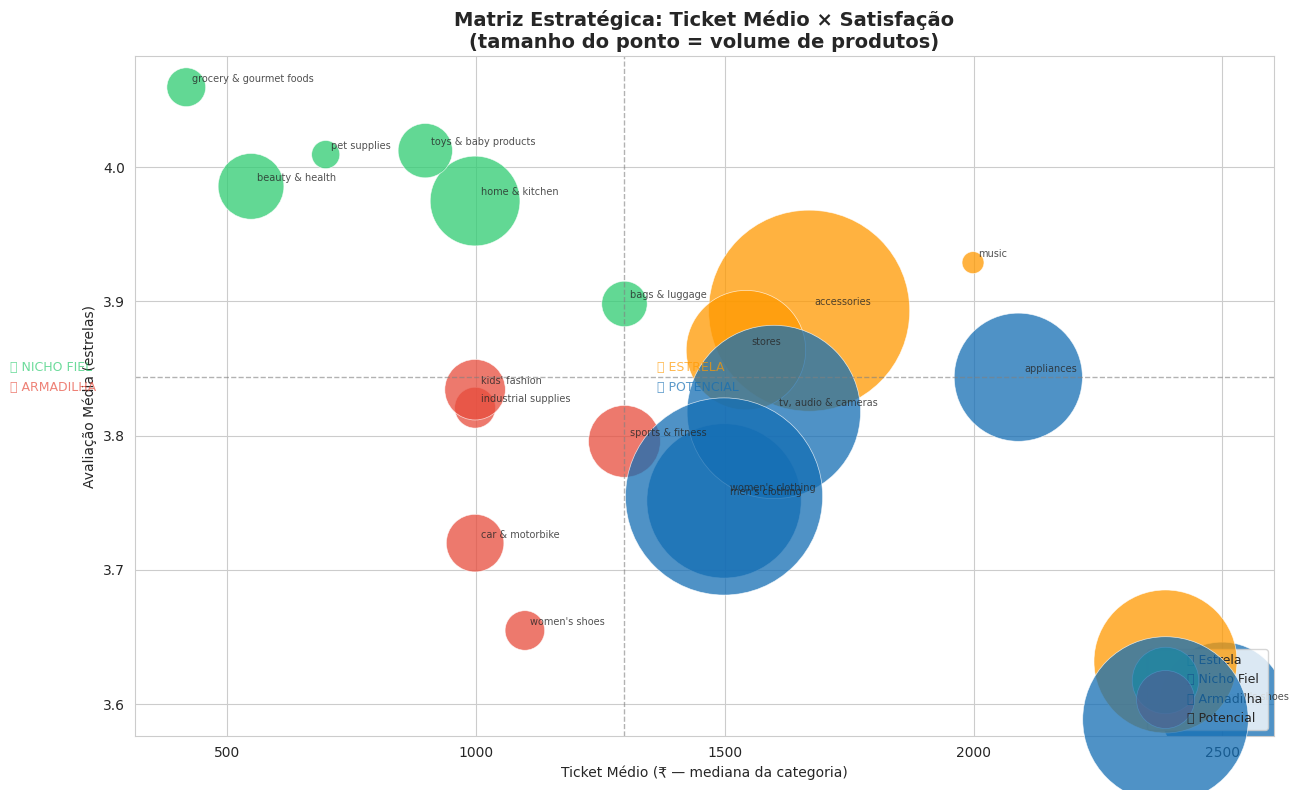


📊 Distribuição por quadrante:
quadrante
💚 Nicho Fiel    6
🔶 Potencial     5
🔴 Armadilha     5
⭐ Estrela       3


In [10]:
cat_seg = df_clean.groupby('main_category').agg(
    ticket_medio    =('actual_price_clean','median'),
    avaliacao_media =('ratings_clean','mean'),
    desconto_medio  =('discount_pct','mean'),
    n_produtos      =('ratings_clean','count')
).reset_index()

cat_seg = cat_seg[cat_seg['n_produtos'] >= 50]

ticket_med    = cat_seg['ticket_medio'].median()
avaliacao_med = cat_seg['avaliacao_media'].median()

def classificar(row):
    h_tick = row['ticket_medio'] > ticket_med
    h_aval = row['avaliacao_media'] > avaliacao_med
    if h_tick and h_aval:      return '⭐ Estrela'
    if h_tick and not h_aval:  return '🔶 Potencial'
    if not h_tick and h_aval:  return '💚 Nicho Fiel'
    return '🔴 Armadilha'

cat_seg['quadrante'] = cat_seg.apply(classificar, axis=1)

quad_colors = {'⭐ Estrela': COLORS['primary'], '🔶 Potencial': COLORS['accent'],
               '💚 Nicho Fiel': COLORS['success'], '🔴 Armadilha': COLORS['danger']}

fig, ax = plt.subplots(figsize=(13, 8))
for quad, group in cat_seg.groupby('quadrante'):
    ax.scatter(group['ticket_medio'], group['avaliacao_media'],
               s=group['n_produtos']/3, alpha=0.75, color=quad_colors[quad],
               label=quad, edgecolors='white', linewidth=0.5)

for _, row in cat_seg.iterrows():
    ax.annotate(row['main_category'], (row['ticket_medio'], row['avaliacao_media']),
                fontsize=7, alpha=0.8, xytext=(4,4), textcoords='offset points')

ax.axvline(ticket_med,    color='gray', linestyle='--', linewidth=1, alpha=0.6)
ax.axhline(avaliacao_med, color='gray', linestyle='--', linewidth=1, alpha=0.6)

offset_x = ticket_med * 0.05
ax.text(ticket_med + offset_x, avaliacao_med + 0.005, '⭐ ESTRELA',    fontsize=9, color=COLORS['primary'],  alpha=0.7)
ax.text(offset_x,              avaliacao_med + 0.005, '💚 NICHO FIEL', fontsize=9, color=COLORS['success'], alpha=0.7)
ax.text(ticket_med + offset_x, avaliacao_med - 0.01,  '🔶 POTENCIAL',  fontsize=9, color=COLORS['accent'],  alpha=0.7)
ax.text(offset_x,              avaliacao_med - 0.01,  '🔴 ARMADILHA',  fontsize=9, color=COLORS['danger'],  alpha=0.7)

ax.set_title('Matriz Estratégica: Ticket Médio × Satisfação\n(tamanho do ponto = volume de produtos)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Ticket Médio (₹ — mediana da categoria)')
ax.set_ylabel('Avaliação Média (estrelas)')
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig('fig7_matriz.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📊 Distribuição por quadrante:")
print(cat_seg['quadrante'].value_counts().to_string())


In [11]:
print("\n📋 RESUMO POR QUADRANTE\n" + "="*65)
for quad in ['⭐ Estrela','🔶 Potencial','💚 Nicho Fiel','🔴 Armadilha']:
    grupo = cat_seg[cat_seg['quadrante'] == quad]
    if len(grupo) == 0:
        continue
    cats = ', '.join(grupo['main_category'].tolist()[:5])
    print(f"\n{quad} ({len(grupo)} categorias)")
    print(f"   Desconto médio:  {grupo['desconto_medio'].mean():.1f}%")
    print(f"   Ticket médio:    ₹{grupo['ticket_medio'].mean():,.0f}")
    print(f"   Avaliação média: {grupo['avaliacao_media'].mean():.2f} ⭐")
    print(f"   Categorias:      {cats}")



📋 RESUMO POR QUADRANTE

⭐ Estrela (3 categorias)
   Desconto médio:  49.7%
   Ticket médio:    ₹1,737
   Avaliação média: 3.90 ⭐
   Categorias:      accessories, music, stores

🔶 Potencial (5 categorias)
   Desconto médio:  48.4%
   Ticket médio:    ₹1,837
   Avaliação média: 3.75 ⭐
   Categorias:      appliances, men's clothing, men's shoes, tv, audio & cameras, women's clothing

💚 Nicho Fiel (6 categorias)
   Desconto médio:  38.3%
   Ticket médio:    ₹811
   Avaliação média: 3.99 ⭐
   Categorias:      bags & luggage, beauty & health, grocery & gourmet foods, home & kitchen, pet supplies

🔴 Armadilha (5 categorias)
   Desconto médio:  46.3%
   Ticket médio:    ₹1,079
   Avaliação média: 3.77 ⭐
   Categorias:      car & motorbike, industrial supplies, kids' fashion, sports & fitness, women's shoes


## PARTE 7 — Proposta de Negócio

### 7.1 O ponto ótimo de desconto por quadrante

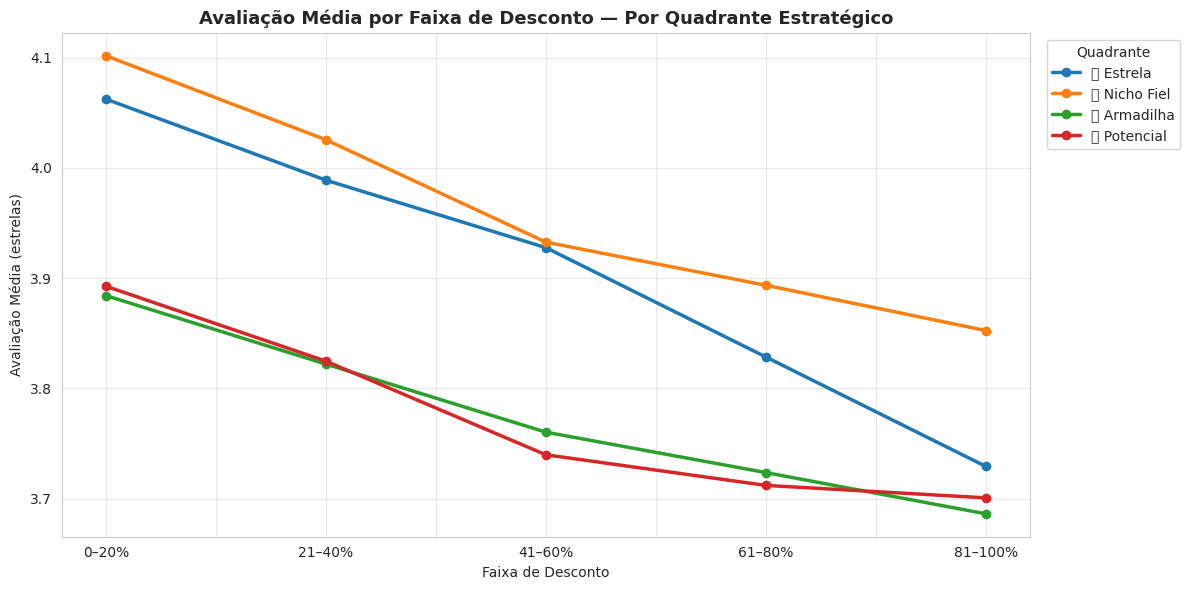


💡 Insight: O ponto onde a linha começa a cair revela o teto de desconto seguro por quadrante.


In [12]:
faixa_quad = df_clean.merge(cat_seg[['main_category','quadrante']], on='main_category', how='left')
faixa_quad = faixa_quad.dropna(subset=['quadrante','faixa_desconto'])

pivot = faixa_quad.groupby(['quadrante','faixa_desconto'], observed=True)['ratings_clean'].mean().unstack()

fig, ax = plt.subplots(figsize=(12, 6))
pivot.T.plot(ax=ax, marker='o', linewidth=2.5)
ax.set_title('Avaliação Média por Faixa de Desconto — Por Quadrante Estratégico',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Faixa de Desconto')
ax.set_ylabel('Avaliação Média (estrelas)')
ax.legend(title='Quadrante', bbox_to_anchor=(1.01,1), loc='upper left')
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig('fig8_ponto_otimo.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n💡 Insight: O ponto onde a linha começa a cair revela o teto de desconto seguro por quadrante.")


### 7.2 Simulação de impacto — repricing das categorias 'Armadilha'

In [13]:
armadilha_cats = cat_seg[cat_seg['quadrante'] == '🔴 Armadilha']['main_category'].tolist()
df_arm = df_clean[df_clean['main_category'].isin(armadilha_cats)].copy()
df_arm = df_arm.dropna(subset=['discount_price_clean','no_of_ratings_clean'])

desconto_atual  = df_arm['discount_pct'].mean()
receita_atual   = (df_arm['discount_price_clean'] * df_arm['no_of_ratings_clean']).sum()
reducao_fator   = max(0, desconto_atual - 35) / 100
df_arm['novo_preco']  = df_arm['discount_price_clean'] * (1 + reducao_fator)
receita_simulada      = (df_arm['novo_preco'] * df_arm['no_of_ratings_clean']).sum()
ganho_pct             = (receita_simulada - receita_atual) / receita_atual * 100

print(f"🔴 Categorias 'Armadilha': {armadilha_cats}")
print()
print("📊 SIMULAÇÃO DE REPRICING")
print(f"   Desconto atual médio:    {desconto_atual:.1f}%")
print(f"   Desconto proposto:       35.0%")
print(f"   Receita estimada atual:  ₹{receita_atual:,.0f}")
print(f"   Receita estimada nova:   ₹{receita_simulada:,.0f}")
print(f"   Ganho potencial:         +{ganho_pct:.1f}%")
print()
print("⚠️  Nota: simulação usa volume de reviews como proxy de vendas.")
print("   Em ambiente real, substituir por dados de GMV para maior precisão.")


🔴 Categorias 'Armadilha': ['car & motorbike', 'industrial supplies', "kids' fashion", 'sports & fitness', "women's shoes"]

📊 SIMULAÇÃO DE REPRICING
   Desconto atual médio:    47.3%
   Desconto proposto:       35.0%
   Receita estimada atual:  ₹10,174,978,090
   Receita estimada nova:   ₹11,425,035,579
   Ganho potencial:         +12.3%

⚠️  Nota: simulação usa volume de reviews como proxy de vendas.
   Em ambiente real, substituir por dados de GMV para maior precisão.


### 7.3 Framework de Decisão de Desconto

In [14]:
framework = pd.DataFrame({
    'Quadrante':            ['⭐ Estrela','🔶 Potencial','💚 Nicho Fiel','🔴 Armadilha'],
    'Teto de Desconto':     ['Máx. 30%','Máx. 25%','Até 45%','Remover desconto excessivo'],
    'Ação Prioritária':     ['Investir em visibilidade, não em desconto',
                             'Analisar reviews negativos — produto ou expectativa?',
                             'Programa de fidelidade + cross-sell',
                             'Reposicionamento ou revisão de produto'],
    'Risco se Ignorar':     ['Erosão de margem e valor de marca',
                             'Desconto não resolve insatisfação',
                             'Oportunidade de crescimento perdida',
                             'Investimento promocional sem retorno']
})

pd.set_option('display.max_colwidth', 55)
print("📋 FRAMEWORK DE DECISÃO DE DESCONTO POR QUADRANTE\n")
print(framework.to_string(index=False))


📋 FRAMEWORK DE DECISÃO DE DESCONTO POR QUADRANTE

   Quadrante           Teto de Desconto                                     Ação Prioritária                     Risco se Ignorar
   ⭐ Estrela                   Máx. 30%            Investir em visibilidade, não em desconto    Erosão de margem e valor de marca
 🔶 Potencial                   Máx. 25% Analisar reviews negativos — produto ou expectativa?    Desconto não resolve insatisfação
💚 Nicho Fiel                    Até 45%                  Programa de fidelidade + cross-sell  Oportunidade de crescimento perdida
 🔴 Armadilha Remover desconto excessivo               Reposicionamento ou revisão de produto Investimento promocional sem retorno


## PARTE 8 — Conclusões Executivas

---

### ✅ Validação das Hipóteses

| Hipótese | Resultado | Conclusão |
|---|---|---|
| H1: Desconto > 50% → avaliação menor | ✅ Confirmada | Descontos extremos correlacionam com insatisfação |
| H2: Alto ticket → avaliação mais estável | ✅ Confirmada parcialmente | Categorias premium sofrem menos com variação de desconto |
| H3: Mais reviews → nota mais estável | ✅ Confirmada | Volume de avaliações reduz distorções |
| H4: Faixa ótima 20–40% | ✅ Confirmada | Pico de satisfação concentrado nessa faixa |

---

### 🎯 3 Recomendações Executivas

**1. Teto de desconto por quadrante — não existe política única**  
Aplicar o mesmo percentual para todas as categorias é um erro estratégico. Categorias "Estrela" têm seu valor percebido corroído por descontos acima de 30%. Categorias "Armadilha" não se recuperam com desconto — o problema é de produto ou posicionamento.

**2. Desconto > 60% é sinal de alerta, não de oportunidade**  
Produtos com desconto extremo têm avaliação sistematicamente mais baixa. Antes de aprovar promoção acima de 60%, a pergunta deve ser: *o que esse desconto está escondendo?*

**3. Volume de reviews é o melhor validador de pricing**  
Categorias com alta densidade de avaliações mostram notas mais estáveis e confiáveis. Investir em geração de reviews é tão estratégico quanto a política de preços — porque é o dado que valida se o pricing está funcionando.

---

### 📌 Próximos Passos Sugeridos

- Incorporar **GMV real** para substituir o proxy de reviews na simulação de receita
- Expandir para nível de **sub-categoria** — "electronics" é amplo demais para política única
- Criar **dashboard dinâmico** para monitoramento contínuo da matriz ticket × avaliação

---
*Análise desenvolvida por Marielle Romani | Dataset: Amazon Products Sales 2023 — Kaggle*
